# Skill spotting eval

This notebook **reads a finished run**. It does not call the LLM and does not rebuild folds.

## What the experiment is for

ReviewDistill exports `SKILL.md` (procedure + each selected label’s definition and examples). Nothing in the product tests whether an agent can use that file to **name the same labels** the author labeled. This experiment is that test, on held-out passages.

Question: does the current skill beat a **names-only baseline** at exact type-name match?

Scores are **diagnostic**, not a pass/fail gate. 0.00 is a real score (no exact matches), not a failed load.

## What a run contains

Produced by `python experiments/skill-eval/run.py` (see `README.md` in this folder):

| File | Role |
|------|------|
| `meta.json` | Holdout mode, provider, fold sizes |
| `items.jsonl` | Passages + gold type names + distractor flag |
| `predictions.jsonl` | Parsed type names + raw reply, per condition (`skill` / `baseline`) |
| `metrics.json` | Exact P/R/F1, hierarchical recall, per-type confusion |

**Gold item:** working-set comment with an accepted active type. The model saw `context_text` (Citations/Refs stripped), never `raw_text`.

**Distractor:** unused prose paragraph from the same paper (not preamble / `\\end{document}`). Gold is `[]`. Any predicted name is a false positive.

**Skill vs baseline:** same items. Skill gets the exported markdown with *test-comment examples stripped*. Baseline gets the same `##` heading names without definitions or examples. Invented names that are not headings never count as hits. `--source store` is the real personal check; a fixture F1 of 1.0 is the toy pack being easy.

This cell loads the **latest fixture** run (`meta.source == "fixture"`) under `experiments/skill-eval/runs/`. It skips store runs so committed outputs stay fictional.

To plot a personal store run, set `SOURCE = "store"` in the next cell and **do not commit** those outputs.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# Resolve runs/ whether the kernel cwd is the repo root or this folder.
HERE = Path.cwd().resolve()
candidates = []
if HERE.name == "skill-eval":
    candidates.append(HERE / "runs")
candidates.append(HERE / "experiments/skill-eval/runs")
candidates.extend(parent / "experiments/skill-eval/runs" for parent in HERE.parents)
RUNS = next((path for path in candidates if path.is_dir()), None)
if RUNS is None:
    raise FileNotFoundError("No experiments/skill-eval/runs folder. Run python experiments/skill-eval/run.py first.")
# "store" plots private passages. Do not commit those outputs.
SOURCE = "fixture"

def run_source(path: Path) -> str | None:
    try:
        return json.loads((path / "meta.json").read_text()).get("source")
    except OSError:
        return None

finished = sorted(
    path for path in RUNS.iterdir()
    if (path / "meta.json").is_file() and run_source(path) == SOURCE
)
if not finished:
    raise FileNotFoundError(
        f"No completed {SOURCE!r} runs in {RUNS}. "
        f"Run python experiments/skill-eval/run.py --source {SOURCE}"
    )
RUN_DIR = finished[-1]
print("Using", RUN_DIR.name, "source=", SOURCE)

def load_jsonl(path: Path):
    rows = []
    for line in path.read_text().splitlines():
        if line.strip():
            rows.append(json.loads(line))
    return rows

meta = json.loads((RUN_DIR / "meta.json").read_text())
metrics = json.loads((RUN_DIR / "metrics.json").read_text())
items = load_jsonl(RUN_DIR / "items.jsonl")
preds = load_jsonl(RUN_DIR / "predictions.jsonl")
items_by_id = {row["id"]: row for row in items}
meta, {k: v["exact"] for k, v in metrics.items()}


Using 20260915T155325Z source= fixture


({'source': 'fixture',
  'holdout': 'paper',
  'comment_fraction': None,
  'seed': 0,
  'provider': 'deepseek',
  'model': 'deepseek-chat',
  'n_gold_comments': 3,
  'n_items': 6,
  'privacy_warning': "Sending 6 review comment(s) plus nearby manuscript context and candidate label definitions to external LLM provider 'deepseek'. The rest of the repository is not sent.",
  'folds': [{'id': 'paper-a',
    'n_gold': 2,
    'n_distractors': 2,
    'distractor_skip': None},
   {'id': 'paper-b',
    'n_gold': 1,
    'n_distractors': 1,
    'distractor_skip': None}]},
 {'baseline': {'precision': 0.42857142857142855,
   'recall': 1.0,
   'f1': 0.6,
   'tp': 3,
   'fp': 4,
   'fn': 0},
  'skill': {'precision': 0.75,
   'recall': 1.0,
   'f1': 0.8571428571428571,
   'tp': 3,
   'fp': 1,
   'fn': 0}})

## Headline: exact type-name match

Micro precision / recall / F1 over **all items** (gold passages + distractors), comparing predicted names to gold names as sets.

- **tp** — predicted name equals a gold name
- **fp** — extra name (including any name on a distractor)
- **fn** — gold name the model missed (`[]` on a gold passage is fn for every gold name)

**Hierarchical recall** (table only) also counts a hit if the model named an *ancestor* of the gold type. Precision stays exact: extras still cost.

A bar of height **0.00 is a real score**. Check `tp`/`fp`/`fn`: skill often returns `[]` (fn = n gold names); baseline often invents non-taxonomy names (fp high, tp still 0).

,condition,tp,fp,fn,precision,recall,f1,hierarchical_recall
0,baseline,3,4,0,0.428571,1.0,0.600000,1.0
1,skill,3,1,0,0.750000,1.0,0.857143,1.0


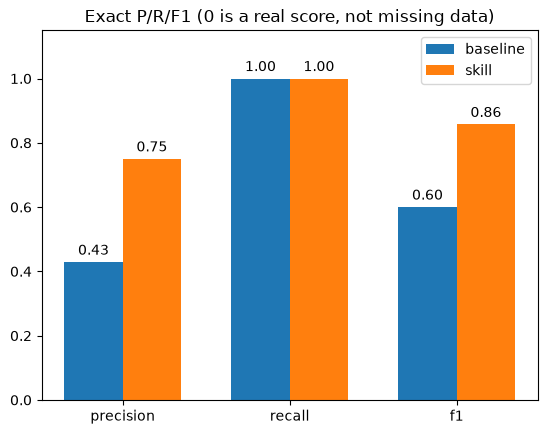

In [2]:
rows = []
for condition in ("baseline", "skill"):
    exact = metrics[condition]["exact"]
    rows.append(
        {
            "condition": condition,
            "tp": exact["tp"],
            "fp": exact["fp"],
            "fn": exact["fn"],
            "precision": exact["precision"],
            "recall": exact["recall"],
            "f1": exact["f1"],
            "hierarchical_recall": metrics[condition]["hierarchical_recall"],
        }
    )
display(pd.DataFrame(rows))

fig, ax = plt.subplots()
labels = ["precision", "recall", "f1"]
x = list(range(len(labels)))
width = 0.35
base = [metrics["baseline"]["exact"][k] for k in labels]
skill = [metrics["skill"]["exact"][k] for k in labels]
bars_b = ax.bar([i - width / 2 for i in x], base, width, label="baseline")
bars_s = ax.bar([i + width / 2 for i in x], skill, width, label="skill")
ax.bar_label(bars_b, fmt="%.2f", padding=3)
ax.bar_label(bars_s, fmt="%.2f", padding=3)
ax.set_xticks(x, labels)
ax.set_ylim(0, 1.15)
ax.set_title("Exact P/R/F1 (0 is a real score, not missing data)")
ax.legend()
plt.show()


## Per-type exact recall (skill only)

For each gold type name, `exact / gold` on the skill condition. Shows which labels the skill actually names vs which it never hits.

Empty plot means `metrics.json` has no per-type rows (no gold names in the run).

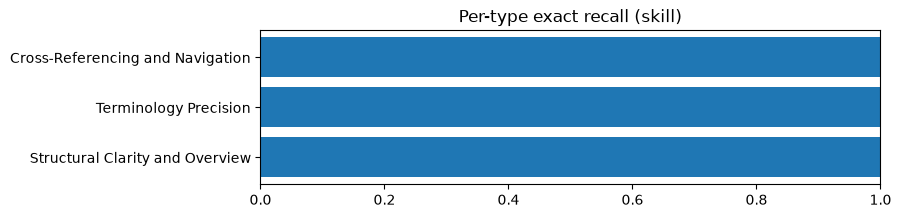

In [3]:
per = metrics["skill"]["per_type"]
if per:
    names = list(per)
    recall = [per[n]["exact"] / per[n]["gold"] if per[n]["gold"] else 0 for n in names]
    fig, ax = plt.subplots(figsize=(8, max(2, 0.4 * len(names))))
    ax.barh(names, recall)
    ax.set_xlim(0, 1)
    ax.set_title("Per-type exact recall (skill)")
    plt.show()
else:
    print("no per-type rows")


## Confusion / substitutions (skill)

One row per gold type name:

- **exact** — predicted that name
- **hierarchical_only** — missed the name but predicted an ancestor
- **miss** — neither
- **top_wrong** — most common extra names predicted on items that had this gold type

Use this when headline F1 is low: is the model silent, naming a parent, or swapping in the wrong sibling?

In [4]:
rows = []
for name, row in metrics["skill"]["per_type"].items():
    rows.append(
        {
            "type": name,
            "gold": row["gold"],
            "exact": row["exact"],
            "hierarchical_only": row["hierarchical_only"],
            "miss": row["miss"],
            "top_wrong": row["top_wrong"],
        }
    )
pd.DataFrame(rows)


,type,gold,exact,hierarchical_only,miss,top_wrong
0,Structural Clarity and Overview,1,1,0,0,[]
1,Terminology Precision,1,1,0,0,[]
2,Cross-Referencing and Navigation,1,1,0,0,[]


## Miss table (skill)

Items where the skill condition did **not** cover every gold name (`gold` ⊈ `predicted`). Includes gold passages the model answered `[]` on.

Distractors do not appear here unless they somehow have gold names (they should not). False positives on distractors show up in headline `fp`, not this table.

This table lists item id, gold, and predicted only. Open `items.jsonl` locally if you need the passage; do not commit store passages.

In [5]:
misses = []
for pred in preds:
    item = items_by_id[pred["item_id"]]
    gold = set(item["gold_names"])
    predicted = set(pred["predicted"])
    if pred["condition"] != "skill":
        continue
    if gold <= predicted:
        continue
    misses.append(
        {
            "item_id": item["id"],
            "is_distractor": item["is_distractor"],
            "gold": item["gold_names"],
            "predicted": pred["predicted"],
            "parse_error": pred.get("parse_error", False),
        }
    )
pd.DataFrame(misses)


""
